<a href="https://colab.research.google.com/github/A-Kester/csci-451/blob/main/docs/live-notebooks/51-text-generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Generation

The rise of Dr. Sus

In this set of notes, we’ll begin our discussion of *generative language models*:

<span class="theorem-title">**Definition 1 (Generative Language Model)**</span> A *generative language model* is a machine learning model whose primary functionality is to produce sequences of useful text.

Our aim by the end of these notes is to have a first, functioning generative language model that can produce text in the style of a piece of sample text. We’ll continue our experiments with the Dr. Seuss data set that we explored last time. Accordingly, our generative language model will be named: ***Dr. Sus***.

In [1]:
import torch
from torch import nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import urllib
import pandas as pd
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

# for appearance
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"

import sys
if "google.colab" in sys.modules:
    !pip install torchinfo
    pio.renderers.default = 'colab'
else:
    pio.renderers.default = "notebook_connected"

from torchinfo import summary

We’ll continue with our experiments on the Dr. Seuss corpus that we studied [last time](50-tokens-embeddings.qmd).

In [2]:
url = "https://raw.githubusercontent.com/PhilChodrow/ml-notes-update/refs/heads/main/data/seuss.txt"
text = "\n".join([line.decode('utf-8').strip() for line in urllib.request.urlopen(url)])

### Pretrained Embedding

Before we introduce our main paradigm and model for text generation, we are going to produce a token embedding for our corpus using the same method as in the previous chapter. The code block below reproduces several steps from the previous chapter, including tokenization, dataset construction, and embedding training.

Figure 1

In [3]:
# construct tokenizer
from tokenizers import Tokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM

# dataset for embedding
from torch.utils.data import Dataset, DataLoader
class CBOWDataset(Dataset):
    def __init__(self, tokens, context_length):
        self.tokens = tokens

        # dict to remap tokens to contiguous integers
        self.token_to_idx = {token: i for i, token in enumerate(set(tokens))}
        self.idx_to_token = {i: token for token, i in self.token_to_idx.items()}

        # context length is the number of tokens on either side of the target token
        self.context_length = context_length
        self.data = []
        for i in range(context_length, len(tokens)-context_length):
            for j in range(-context_length, context_length+1):
                if j != 0:
                    self.data.append((self.token_to_idx[tokens[i+j]], self.token_to_idx[tokens[i]]))
                    self.data.append((self.token_to_idx[tokens[i+j]], self.token_to_idx[tokens[i]]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx][0]), torch.tensor(self.data[idx][1])

# CBOW embedding model
class CBOW(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, d_embedding)
        self.linear = nn.Linear(d_embedding, vocab_size)

    def forward(self, x):
        embedded = self.embeddings(x)
        output = self.linear(embedded)
        return output

# for embedding visualization after training
def visualize_embeddings(model, tokenizer, data):

    # extract the embedding weights
    weights = model.embeddings.weight

    # use t-SNE to reduce the dimensionality of the embeddings to 2D
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(weights.detach().cpu().numpy())

    # make a dataframe for plotly
    embedding_df = pd.DataFrame(embeddings_2d, columns=["Dim1", "Dim2"])
    embedding_df["Token"] = [tokenizer.decode(data.idx_to_token[i]) for i in range(len(embeddings_2d))]

    # labeled scatter plot of the embeddings
    fig = px.scatter(embedding_df, x="Dim1", y="Dim2", text="Token", title="2D Visualization of Token Embeddings")
    fig.update_traces(textposition='top center')
    fig.update_layout(xaxis_title="Dimension 1", yaxis_title="Dimension 2")
    fig.show()

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    checkpoint = "openai-community/gpt2"
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)


    # construct dataset, dataloader, model
    context_length = 5
    tokens = tokenizer.encode(text)
    data = CBOWDataset(tokens, context_length=context_length)
    dataloader = DataLoader(data, batch_size=32, shuffle=True)
    vocab_size = len(data.token_to_idx)
    d_embedding = 8
    model = CBOW(vocab_size, d_model=d_embedding)

    # construct training loss and optimizer

    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    loss_fn = nn.CrossEntropyLoss()
    model.to(device)

    # training loop
    for epoch in range(5):
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            opt.zero_grad()
            output = model(X_batch)
            loss = loss_fn(output, y_batch)
            loss.backward()
            opt.step()

    # take a look at the embeddings
    visualize_embeddings(model, tokenizer, data)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (11051 > 1024). Running this sequence through the model will result in indexing errors


Importantly, we’re now able to extract the embedding layer from our CBOW model. We can then use the *same* embedding layer in a future model, without the need to train it again. Since we don’t need to train the embedding further, we can turn off tracking of gradient information for this layer.

In [4]:
embedding = model.embeddings
embedding.requires_grad_(False)
embedding = embedding.to(device)
test_token = torch.tensor([1]).to(device)
embedding(test_token)

tensor([[-1.2615,  0.1696, -0.1871, -0.0176, -0.4282,  1.1334,  0.3358, -0.1588]],
       device='cuda:0')

## Next-Token Prediction

The current dominant paradigm in generative language modeling is called *next-token prediction*. The idea is to train a model to predict the next token in a sequence of tokens, given the previous tokens:

<span class="theorem-title">**Definition 2 (Next-Token Prediction)**</span> In *next-token prediction*, we treat a sequence of tokens $t_1,t_2,\ldots,t_k$ as a set of *features*, and attempt to use them to predict the identity of the next token $t_{k+1}$ in the sequence.

> **Next-Token Prediction is a Classification Problem**
>
> Since the possible values of a given token come from the discrete set of token ids in the vocabulary, we can view next-token prediction as a *classification problem*: given a sequence of tokens, we want to classify the identity of the next token.

#### Context Length and N-Gram Models

There are many different kinds of models which aim to solve the next-token prediction problem. For this chapter, we’ll focus on a simple class of models called *n-gram* models, which use a fixed number of previous tokens as features to predict the next token.

<span class="theorem-title">**Definition 3 (Context Length, N-Gram Models)**</span> The *context length* is the number of previous tokens that we use as features to predict the next token in a next-token prediction problem.

A model that uses a fixed context length of $n$ is often called an *(n+1)-gram* model.

For example, a model with context length 1 is often called a *bigram* model, since it encodes relationships between pairs of tokens (one feature, one target). A model with context length 2 is often called a *trigram* model, since it encodes relationships between triples of tokens (two features, one target).

### Datasets for Next-Token Prediction

We’re now ready to implement a data set for next-token prediction using an $n$-gram model. To do this, we need to organize our sequence of token ids into a data set of training examples, in which each example consists of a sequence of tokens as features and the next token as the target. We can implement this using a custom `Dataset` class in PyTorch. In the `__init__` method we save several instance variables and tokenize the input text, while in the `__len__` and `__getitem__` methods we implement the logic for how to index into the data set to get the features and target for each example.

<span class="column-margin margin-aside">For convenience purposes only, we’ve arranged for the dataset to return both the token ids and the corresponding text for each example. In practice, only the token ids are needed for training – the text is just for debugging and our own entertainment.</span>

In [6]:
class SeussDataSet(Dataset):
    def __init__(self, tokens, context_length = 5): # gives 5 tokens at a time (features), then next token (target)
        self.context_length = context_length
        self.tokens = tokens
        self.vocab_length = len(set(tokens))
        self.idx_to_token = {i: token for i, token in enumerate(set(tokens))}
        self.token_to_idx = {token: i for i, token in enumerate(set(tokens))}


    def __len__(self):
        return len(self.tokens) - self.context_length

    def __getitem__(self, key):

        target_token = self.tokens[self.context_length + key]
        target = torch.tensor(self.token_to_idx[target_token]) # reducing vocab size

        feature_tokens = self.tokens[key:(self.context_length + key)]
        features = [self.token_to_idx[token] for token in feature_tokens]

        feature_tensor = torch.tensor(features, dtype=torch.long)

        return feature_tensor.to(device), target.to(device)

For convenience later, we’re also going to implement a simple class that decodes the tokens. The entire puprose of this class is to wrap up the `tokenizer` and the `token_to_idx` map used by our dataset and model; we’ll use this when we get to text generation.

In [7]:
class SeussDecoder:
    def __init__(self, dataset, tokenizer):
        self.dataset = dataset
        self.idx_to_token = dataset.idx_to_token
        self.token_to_idx = dataset.token_to_idx
        self.tokenizer = tokenizer

    def decode(self, token_indices):
        tokens = [self.idx_to_token[idx] for idx in token_indices]
        return self.tokenizer.decode(tokens)

Let’s instantiate each class:

In [8]:
context_length = 10

data = SeussDataSet(tokens, context_length = context_length)
decoder = SeussDecoder(data, tokenizer)

print(f"Number of training examples: {len(data)}")
print(f"Vocabulary size: {data.vocab_length}")

Number of training examples: 11041
Vocabulary size: 1589


Now that we’ve constructed the data set, we can query it just by indexing:

In [9]:
for i in range(5):
    X, y = data[i]
    X_text = decoder.decode(X.tolist())
    y_text = decoder.decode([y.item()])
    print(f"Example {i:<2}: {X.tolist()} -> {y}")
    print(" " * 10 + ":", end = "")
    print(repr(X_text), end = "")
    print("-->", end = "")
    print(repr(y_text))

Example 0 : [188, 1248, 95, 76, 869, 60, 60, 1069, 593, 7] -> 418
          :'The Cat in the Hat\n\nBy Dr.'-->' Se'
Example 1 : [1248, 95, 76, 869, 60, 60, 1069, 593, 7, 418] -> 433
          :' Cat in the Hat\n\nBy Dr. Se'-->'uss'
Example 2 : [95, 76, 869, 60, 60, 1069, 593, 7, 418, 433] -> 60
          :' in the Hat\n\nBy Dr. Seuss'-->'\n'
Example 3 : [76, 869, 60, 60, 1069, 593, 7, 418, 433, 60] -> 60
          :' the Hat\n\nBy Dr. Seuss\n'-->'\n'
Example 4 : [869, 60, 60, 1069, 593, 7, 418, 433, 60, 60] -> 188
          :' Hat\n\nBy Dr. Seuss\n\n'-->'The'


Let’s add a data loader so that we can train the model with stochastic optimization:

In [10]:
loader = DataLoader(data, batch_size = 256, shuffle = True)

A single batch of data from the loader consists of a tensor of features (token ids) and a tensor of targets (token ids), along with the corresponding text for each example in the batch:

In [11]:
X_batch, y_batch = next(iter(loader))
print(f"Batch of features (token ids): {X_batch.shape}")
print(f"Batch of targets (token ids): {y_batch.shape}")

Batch of features (token ids): torch.Size([256, 10])
Batch of targets (token ids): torch.Size([256])


## Next-Token Prediction with Neural N-Gram Models

We’re now ready to train a simple neural network to perform $n$-gram next-token prediction with one-hot encoded features. For our first approach, we are going to use a simple $n$-gram model, composed only of the pretrained embedding layer, a flattening operation, and some linear processing layers.

Note that our embedding layer in this model is *not* a new embedding layer (`nn.Embedding`, but rather the pretrained embedding that we trained with CBOW).

In [12]:
class SuessModel(nn.Module):
  def __init__(self, vocab_size, context_length, embedding_dim, hidden_dim): # vocab size = number of distinct tokens in text, context_length = how many tokens, not a choice, embedding_dim = 8 (not a choice), hidden_dim is only one can play wtih
    super().__init__()
    self.embeddings = embedding
    self.hidden = nn.Linear(embedding_dim * context_length, hidden_dim)
    self.output = nn.Linear(hidden_dim, vocab_size)

  def forward(self, x):
    embedded = self.embeddings(x)
    embedded = embedded.view(embedded.size(0), -1) # flatten along last axis, same as Flatten()
    hidden_output = self.hidden(embedded)
    hidden_output = torch.relu(hidden_output)
    return self.output(hidden_output)

We’re now ready to instantiate Dr. Sus!

In [13]:
model = SuessModel(
    vocab_size = data.vocab_length,
    context_length = context_length,
    embedding_dim = embedding.weight.shape[1],
    hidden_dim = 128
).to(device)

When passed a sequence of tokens, this model produces an unnormalized probability distribution over possible next tokens:

In [14]:
x, y = data[100]
x = x.unsqueeze(0).to(device) # add batch dimension and move to device
output = model(x) # add batch dimension
print(f"Model output shape: {output.shape}")

Model output shape: torch.Size([1, 1589])


Let’s also take a look at the structure:

In [15]:
summary(model, input_size=(x.shape), device=device, dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
SuessModel                               [1, 1589]                 --
├─Embedding: 1-1                         [1, 10, 8]                (12,712)
├─Linear: 1-2                            [1, 128]                  10,368
├─Linear: 1-3                            [1, 1589]                 204,981
Total params: 228,061
Trainable params: 215,349
Non-trainable params: 12,712
Total mult-adds (Units.MEGABYTES): 0.23
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.91
Estimated Total Size (MB): 0.93

Time to train:

In [16]:
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.005)

loss_history = []
for epoch in range(1000):
    total_loss = 0
    for X_batch, y_batch in loader:
        opt.zero_grad()
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    loss_history.append(total_loss / len(loader))
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss_history[-1]:.4f}")

Epoch 0, Loss: 5.8707
Epoch 100, Loss: 0.0787
Epoch 200, Loss: 0.0331
Epoch 300, Loss: 0.0344
Epoch 400, Loss: 0.0222
Epoch 500, Loss: 0.0215
Epoch 600, Loss: 0.2540
Epoch 700, Loss: 0.0173


KeyboardInterrupt: 

Figure 2: Training loss over epochs for the next-token prediction model.

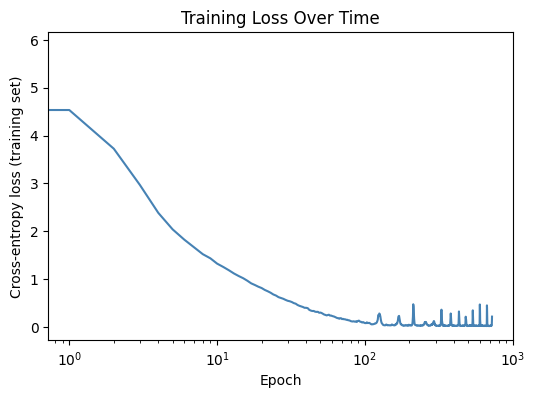

In [17]:
fig, ax = plt.subplots(figsize = (6, 4))
ax.plot(loss_history, color = "steelblue")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss (training set)")
ax.set_title("Training Loss Over Time")
ax.semilogx()
plt.show()

Having trained the model, we can use the `forward` method to get the model’s predicted scores for the next token:

In [19]:
x, y = data[240]
x = x.unsqueeze(0).to(device) # add batch dimension and move to device
output = model(x) # add batch dimension
output.shape # score for each token in vocabulary, higher score is higher probability that it follows the input feature

torch.Size([1, 1589])

A simple method for text generation is just to predict the token that receives the highest score from the model.

In [20]:
t = torch.argmax(output, dim=1).item() # always choosing the highest score is like always picking the middle auto-fill suggestion in imessage

print(repr(decoder.decode(x.tolist()[0])), end = "")
print("-->", end = "")
print(repr(decoder.decode([t])))

' good fun that is funny!"\n\n"I'-->' know'


Deterministic prediction always eventually produces text that repeats itself, so modern approaches typically inject some amount of tunable randomness into the generation process.

### Stochastic Generation via Boltzmann Sampling

In *stochastic prediction*, we treat the scores as defining a probability distribution over the possible next tokens, and we sample from this distribution to get our prediction. The most common choice of probability distribution is the *Boltzmann* distribution.

<span class="theorem-title">**Definition 4 (Boltzman Distribution, Temperature)**</span> Given a vector $\mathbf{s}\in \mathbb{R}^k$ of scores for each of $k$ possible next tokens, the *Boltzmann distribution* is a probability distribution over the $k$ tokens defined by the scores $\mathbf{s}$ and a parameter $T > 0$ called the *temperature*. It has formula

$$
\begin{aligned}
    p(t) = \frac{e^{\beta s_t }}{\sum_{t'} e^{\beta s_{t'} }}\;,
\end{aligned}
$$

where $\beta = 1/T$.

Larger values of $T$ lead to more random predictions, while smaller values of $T$ lead to more deterministic predictions. <span class="column-margin margin-aside">Random predictions are sometimes called “creative” among certain enthusiasts.</span> In the limit as $T \to 0$, the Boltzmann distribution converges to a distribution that puts all of its mass on the token with the highest score, which is exactly what deterministic prediction does. In the limit as $T \to \infty$, the Boltzmann distribution converges to the uniform distribution over all tokens, which corresponds to completely random prediction.

In [21]:
def boltzmann_prediction(preds, temperature = 1.0):
  probabilities = torch.nn.Softmax(dim=0)(preds / temperature) # scores / temp = scores * beta
  return torch.multinomial(probabilities, num_samples = 1).item()

Since the $T \to 0$ limit of the Boltzmann distribution corresponds to deterministic prediction, we can implement deterministic prediction using the `boltzmann_prediction` function by setting the temperature to a very small value.

Let’s try out the Boltzmann prediction function with different values of the temperature parameter:

In [22]:
X, y = data[2000]
preds = model.forward(X.unsqueeze(0)).squeeze(0)

print(f"Feature text: '{repr(decoder.decode(X.tolist()))}'")

for temp in [0.001, 0.5, 2.0]:
    print(f"\nPredictions with temperature {temp}:")
    print("-----------------------------")
    for _ in range(3):
        y_pred = boltzmann_prediction(preds, temperature = temp)
        print(f"Temperature: {temp}, Predicted token: {y_pred}, {decoder.decode([y_pred])}")

Feature text: ''And you take them away!"\n\n"Oh''

Predictions with temperature 0.001:
-----------------------------
Temperature: 0.001, Predicted token: 1282,  dear
Temperature: 0.001, Predicted token: 1282,  dear
Temperature: 0.001, Predicted token: 1282,  dear

Predictions with temperature 0.5:
-----------------------------
Temperature: 0.5, Predicted token: 1282,  dear
Temperature: 0.5, Predicted token: 1282,  dear
Temperature: 0.5, Predicted token: 1282,  dear

Predictions with temperature 2.0:
-----------------------------
Temperature: 2.0, Predicted token: 1282,  dear
Temperature: 2.0, Predicted token: 1282,  dear
Temperature: 2.0, Predicted token: 1282,  dear


For very low temperatures, the predictions are essentially deterministic (we always generate the same prediction), while for higher temperatures, the predictions become more and more random.

## Recurrent Text Generation

To generate text with our trained model, we start with an initial sequence of tokens, and then repeatedly apply the model to predict the next token, appending each predicted token to the sequence and using the updated sequence as the new input for the next prediction.

<figure id="fig-token-prediction">
<img src="attachment:fig/token-prediction.png" />
<figcaption>Figure 3: Illustration of recurrent text generation using word-level tokens and a context length of 2. Each newly-generated token is added to the sequence. The oldest token in the context is dropped, so that the context length remains fixed at 2.</figcaption>
</figure>

The following function implements this logic for generating text with a trained $n$-gram model.

In [23]:
def generate_text(model, decoder, start_tokens, max_length=20, temperature=1.0):
    generated_tokens = start_tokens.copy()

    for _ in range(max_length):
        input_tensor = torch.tensor(generated_tokens[-context_length:], dtype=torch.long).unsqueeze(0).to(device)
        with torch.no_grad():
            preds = model(input_tensor).squeeze(0)

        next_token = boltzmann_prediction(preds, temperature)
        generated_tokens.append(next_token)

    return decoder.decode(generated_tokens)

Let’s use our function to generate text at a few different temperatures. As we might expect, when the temperature is high, the text is essentially random.

In [24]:
start = "Fox socks. box Knox. Knox in box."
tokens = tokenizer.encode(start)
start_tokens = [decoder.token_to_idx[token] for token in tokens]

In [25]:
dr_sus = generate_text(model, decoder, start_tokens, max_length=50, temperature=2.0)
print(dr_sus)

Fox socks. box Knox. Knox in box.
The we.
'I can I I like can do won't chew.
I." then those the a the fish!", the the a
ThenThis is," the fish," is with he head tricks hours and till,.



On the other hand, when the temperature is very low, the text quickly locks into a repetitive pattern.

In [26]:
dr_sus = generate_text(model, decoder, start_tokens, max_length=50, temperature=0.1)
print(dr_sus)

Fox socks. box Knox. Knox in box.
The like's

Sam like not in a.Sam-I-am-
I, like!
I eat not

All fish? will not
Here eggs, sir.
I are not togreen eggs.
I


At intermediate values, we recover something that is still very chaotic but which also contains occasional flashes of coherent task:

In [27]:
dr_sus = generate_text(model, decoder, start_tokens, max_length=50, temperature=0.3)
print(dr_sus)

Fox socks. box Knox. Knox in box.
The like's

Sam like not in a.Sam-I-am-
I, like!
I eat not

All fish? will not do in all socks.
You not see hold new hop aS my would


Further experiments with the model training and temperature parameter may yield more or less coherent text.

## What’s Next?

You may observe that none Dr. Sus’s writings are particularly impressive in terms of their coherence or resemblance to the source material. This reflects:

A very **small training data set**: just the text of four short children’s books.

A **simple model architecture**, with low embedding dimension and no hidden layers.

Perhaps most importantly, a **nonspecialized model architecture** that does not account for any of the distinctive structural features of language. An especially important feature we’re ignoring here is that language is *sequential* and *recombinant* – not only does the order of tokens matter, but the same token can have different meanings in different contexts. There are a variety of model architectures designed to account for the distinctive structural features of sequence data like language, especially *recurrent neural networks* and *transformers*. We’ll discuss models specialized for sequence modeling in the next chapter.